In [1]:
from pathlib import Path

_EXPORT = "comparison3_yolo8n_export"
_RUN = "comparison3_yolo8n"


def _repo_root_with_run() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / _EXPORT / "runs" / _RUN).is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        f"Could not find {_EXPORT}/runs/{_RUN}; run the notebook from the repo root or Analysis/."
    )


BASE = str(_repo_root_with_run() / _EXPORT / "runs" / _RUN)


## **Part V: Multi-Version YOLO Comparison (YOLOv8n)**



### Experimental Settings

This is the third of three comparison models run as part of Part V.
The goal is to compare YOLOv11n (baseline) against other YOLO versions trained under identical conditions to evaluate how architecture differences affect performance on the VisDrone dataset.

All settings were kept identical to the Part I baseline to ensure a fair comparison:

| Setting | Baseline (YOLOv11n) | Comparison 3 (YOLOv8n) |
|---|---|---|
| Dataset | VisDrone2019 | VisDrone2019 |
| Image Size | 640 | 640 |
| Batch Size | 16 | 16 |
| Max Epochs | 200 | 200 |
| Patience | 50 | 50 |
| **Model** | **YOLOv11n** | **YOLOv8n** |

The only difference is the model version. YOLOv8n is a widely used nano detector in the YOLOv8 line; this run checks whether it improves on the baseline when everything else in the training recipe matches your project settings.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = f"{BASE}/results.csv"

df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

# final epoch metrics
final = df.iloc[-1]
print("=== Final Epoch Results ===")
print(f"mAP@50:        {final['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:     {final['metrics/mAP50-95(B)']:.4f}")
print(f"Precision:     {final['metrics/precision(B)']:.4f}")
print(f"Recall:        {final['metrics/recall(B)']:.4f}")
print(f"Train Box Loss:{final['train/box_loss']:.4f}")
print(f"Val Box Loss:  {final['val/box_loss']:.4f}")

=== Final Epoch Results ===
mAP@50:        0.3595
mAP@50-95:     0.2080
Precision:     0.4751
Recall:        0.3487
Train Box Loss:1.3439
Val Box Loss:  1.3647


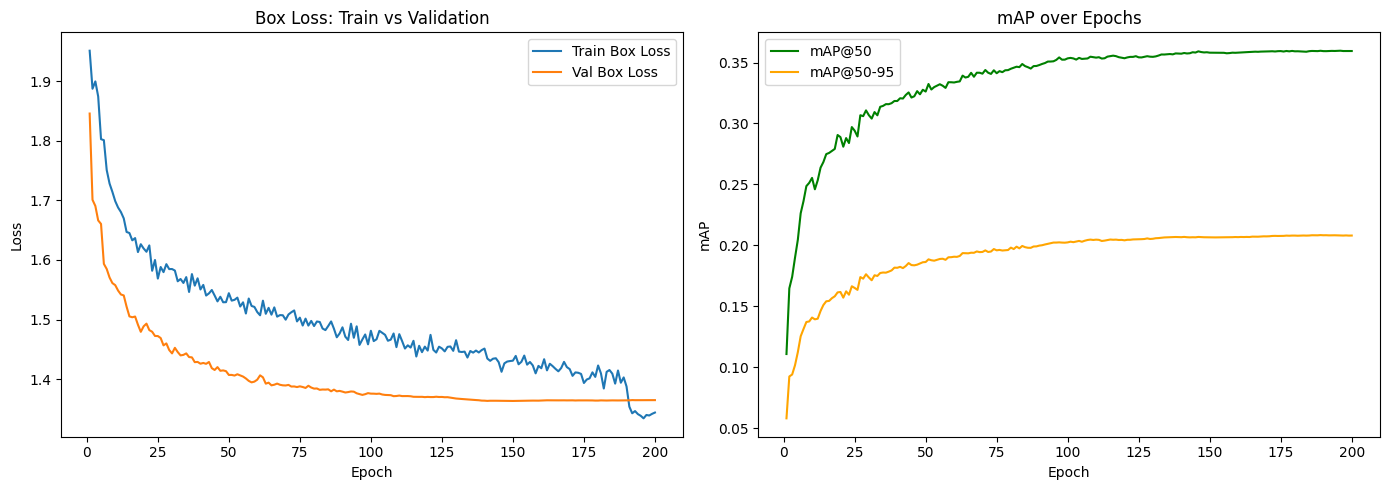

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0].set_title('Box Loss: Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# mAP curve
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
axes[1].set_title('mAP over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/loss_map_curves.png", dpi=150)
plt.show()

In [4]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,200,0.3595,0.208,0.4751,0.3487


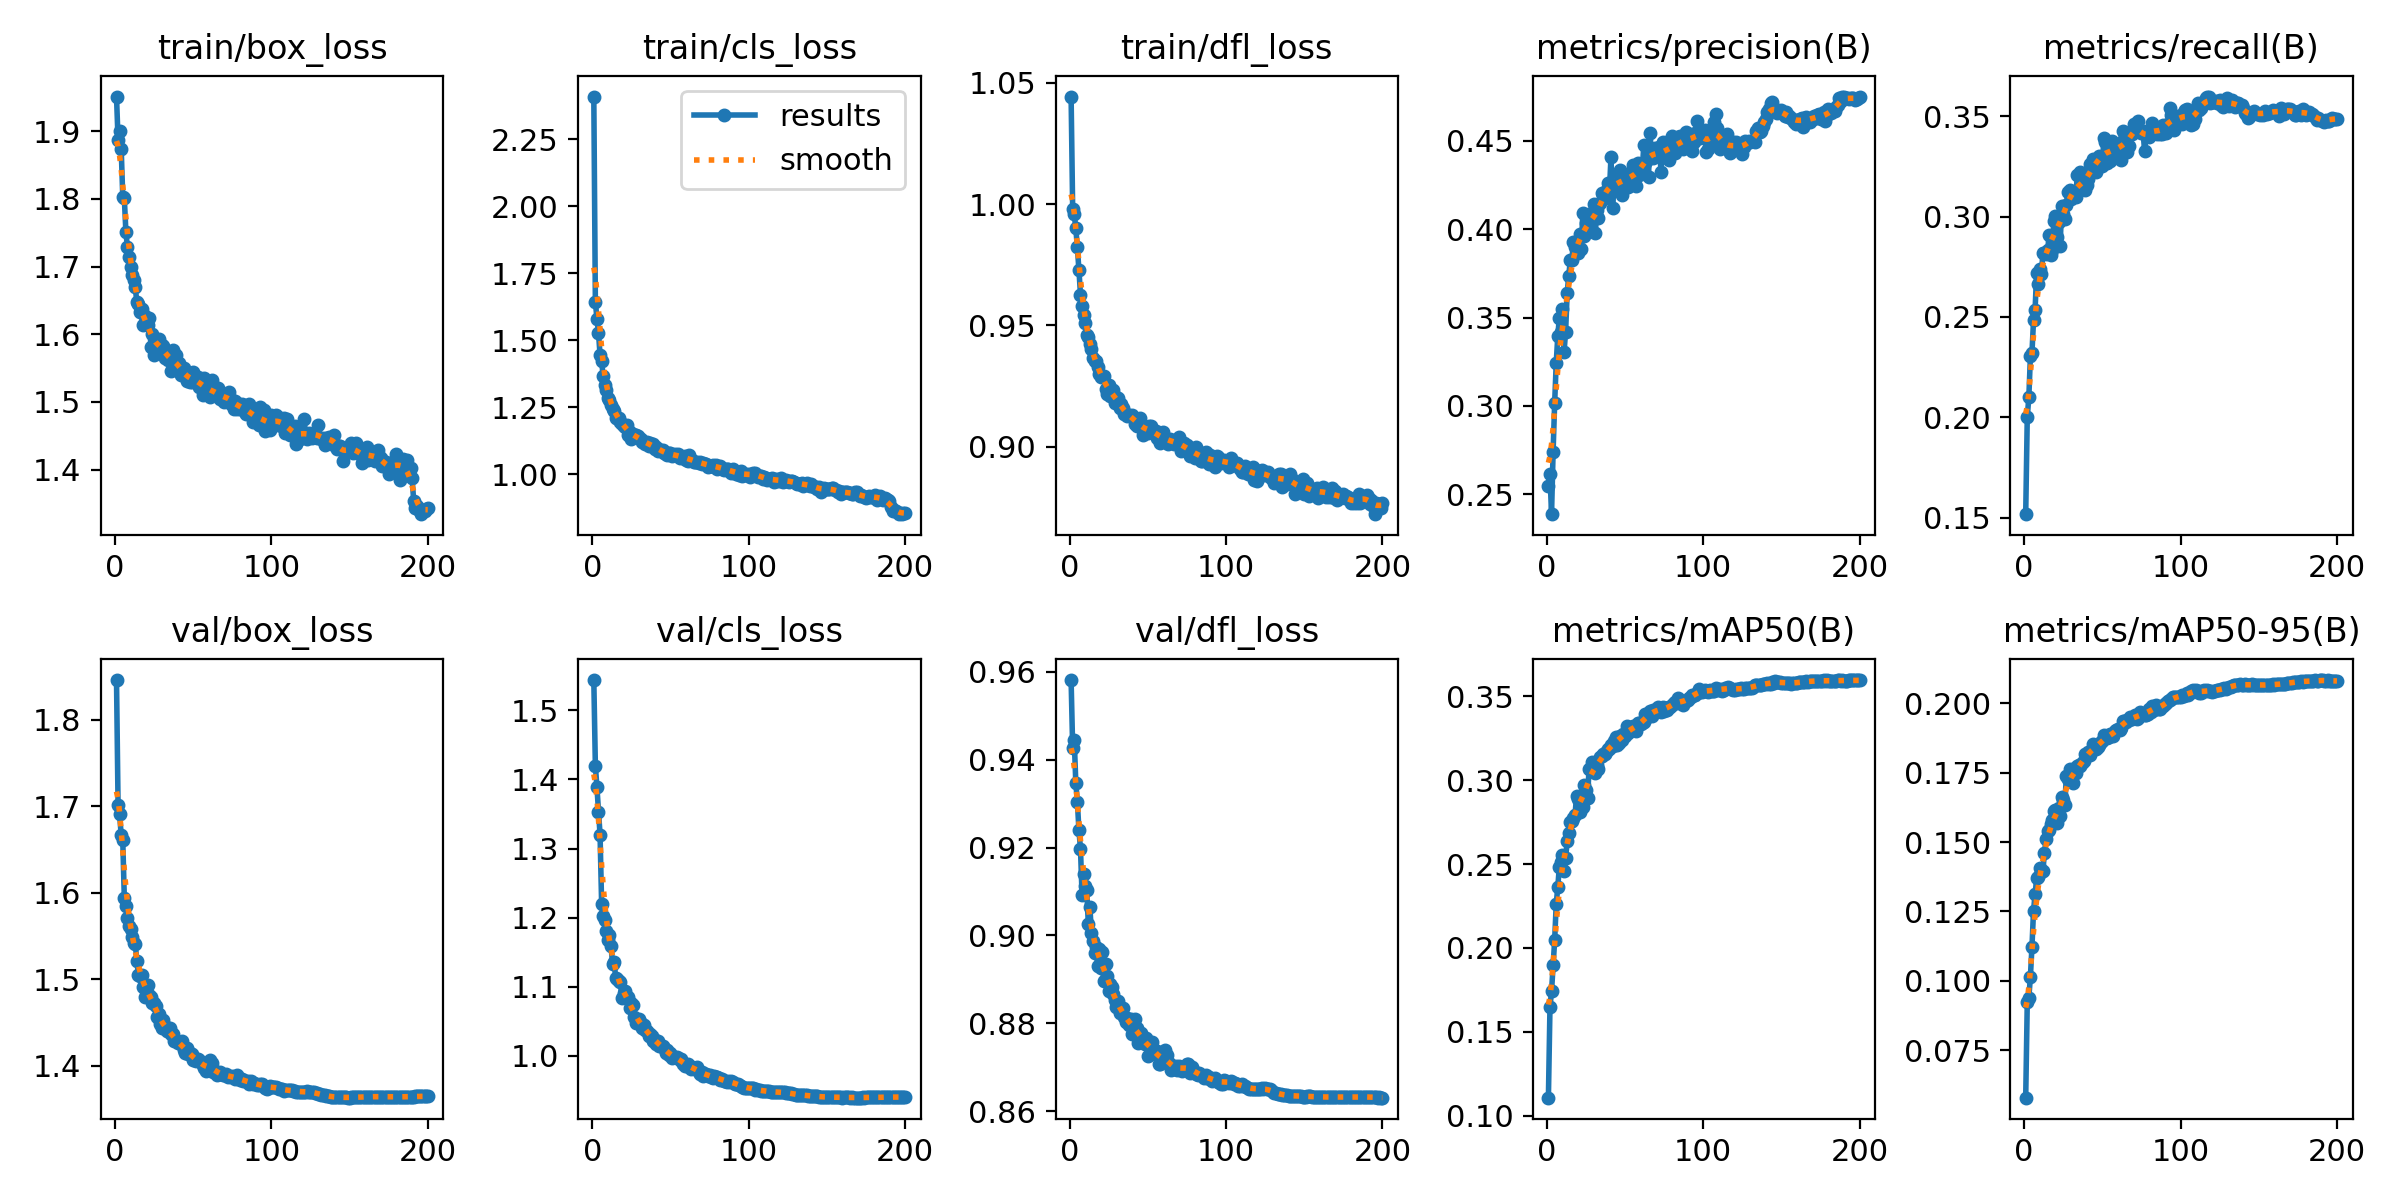

In [5]:
from IPython.display import Image, display
display(Image(f"{BASE}/results.png"))

### **Discussion**

**Note:** 200 epochs were set with a patience of 50 during training. Comparison 3 (YOLOv8n) ran the full 200 epochs, so early stopping did not trigger and training continued through epoch 200. The Part I baseline export stops earlier (final epoch 179), which is expected when early stopping fires under the same patience.

### 1. Training vs. Validation Loss

The loss curves above plot the **box loss** for both the training set and the validation set across all 200 epochs. The key observations are:

- Both curves decrease steadily through training, showing sustained learning.
- The curves slow after roughly epoch 100–120 but still trend downward toward epoch 200.
- At the final epoch (epoch 200), the **training box loss is 1.3439** and the **validation box loss is 1.3647**, a gap of roughly **0.021** (validation slightly higher than training).

That pattern is **mild overfitting**: validation is a bit harder than training, but the gap stays small. It is also **slightly smaller** than the baseline’s train/val box gap (**~0.025** at the baseline’s last epoch), which is a good sign for generalization on box loss in this run.

### 2. Convergence Behavior

Training completed **200 epochs** without patience-based early stopping, so the optimizer was still making small updates late in training.

Headline detection metrics at the end are **strong relative to the baseline**: **mAP@50 ~0.359** and **mAP@50-95 ~0.208**, compared with **~0.349** and **~0.201** for YOLOv11n at its best exported epoch. **Precision (~0.475)** is clearly higher than the baseline (**~0.447**), while **recall (~0.349)** is essentially the same as the baseline (**~0.347**). Overall, YOLOv8n is the comparison model that **most clearly improves** mAP and precision under this fixed recipe.

### 3. Results Curves (results.png)

The results.png panel shows training and validation losses together with precision, recall, mAP@50, and mAP@50-95.

Training and validation losses move in parallel without a sharp late split, which matches the small **~0.021** box-loss gap.

Precision climbs and stabilizes near **0.475**, above the baseline. Recall tracks near **0.35**, in line with the baseline, so the mAP gain is driven more by **cleaner confident detections (precision)** than by finding many more objects.

The spread between **mAP@50 (~0.359)** and **mAP@50-95 (~0.208)** is similar to the baseline, so tight box localization remains the harder part of the task for this model as well.



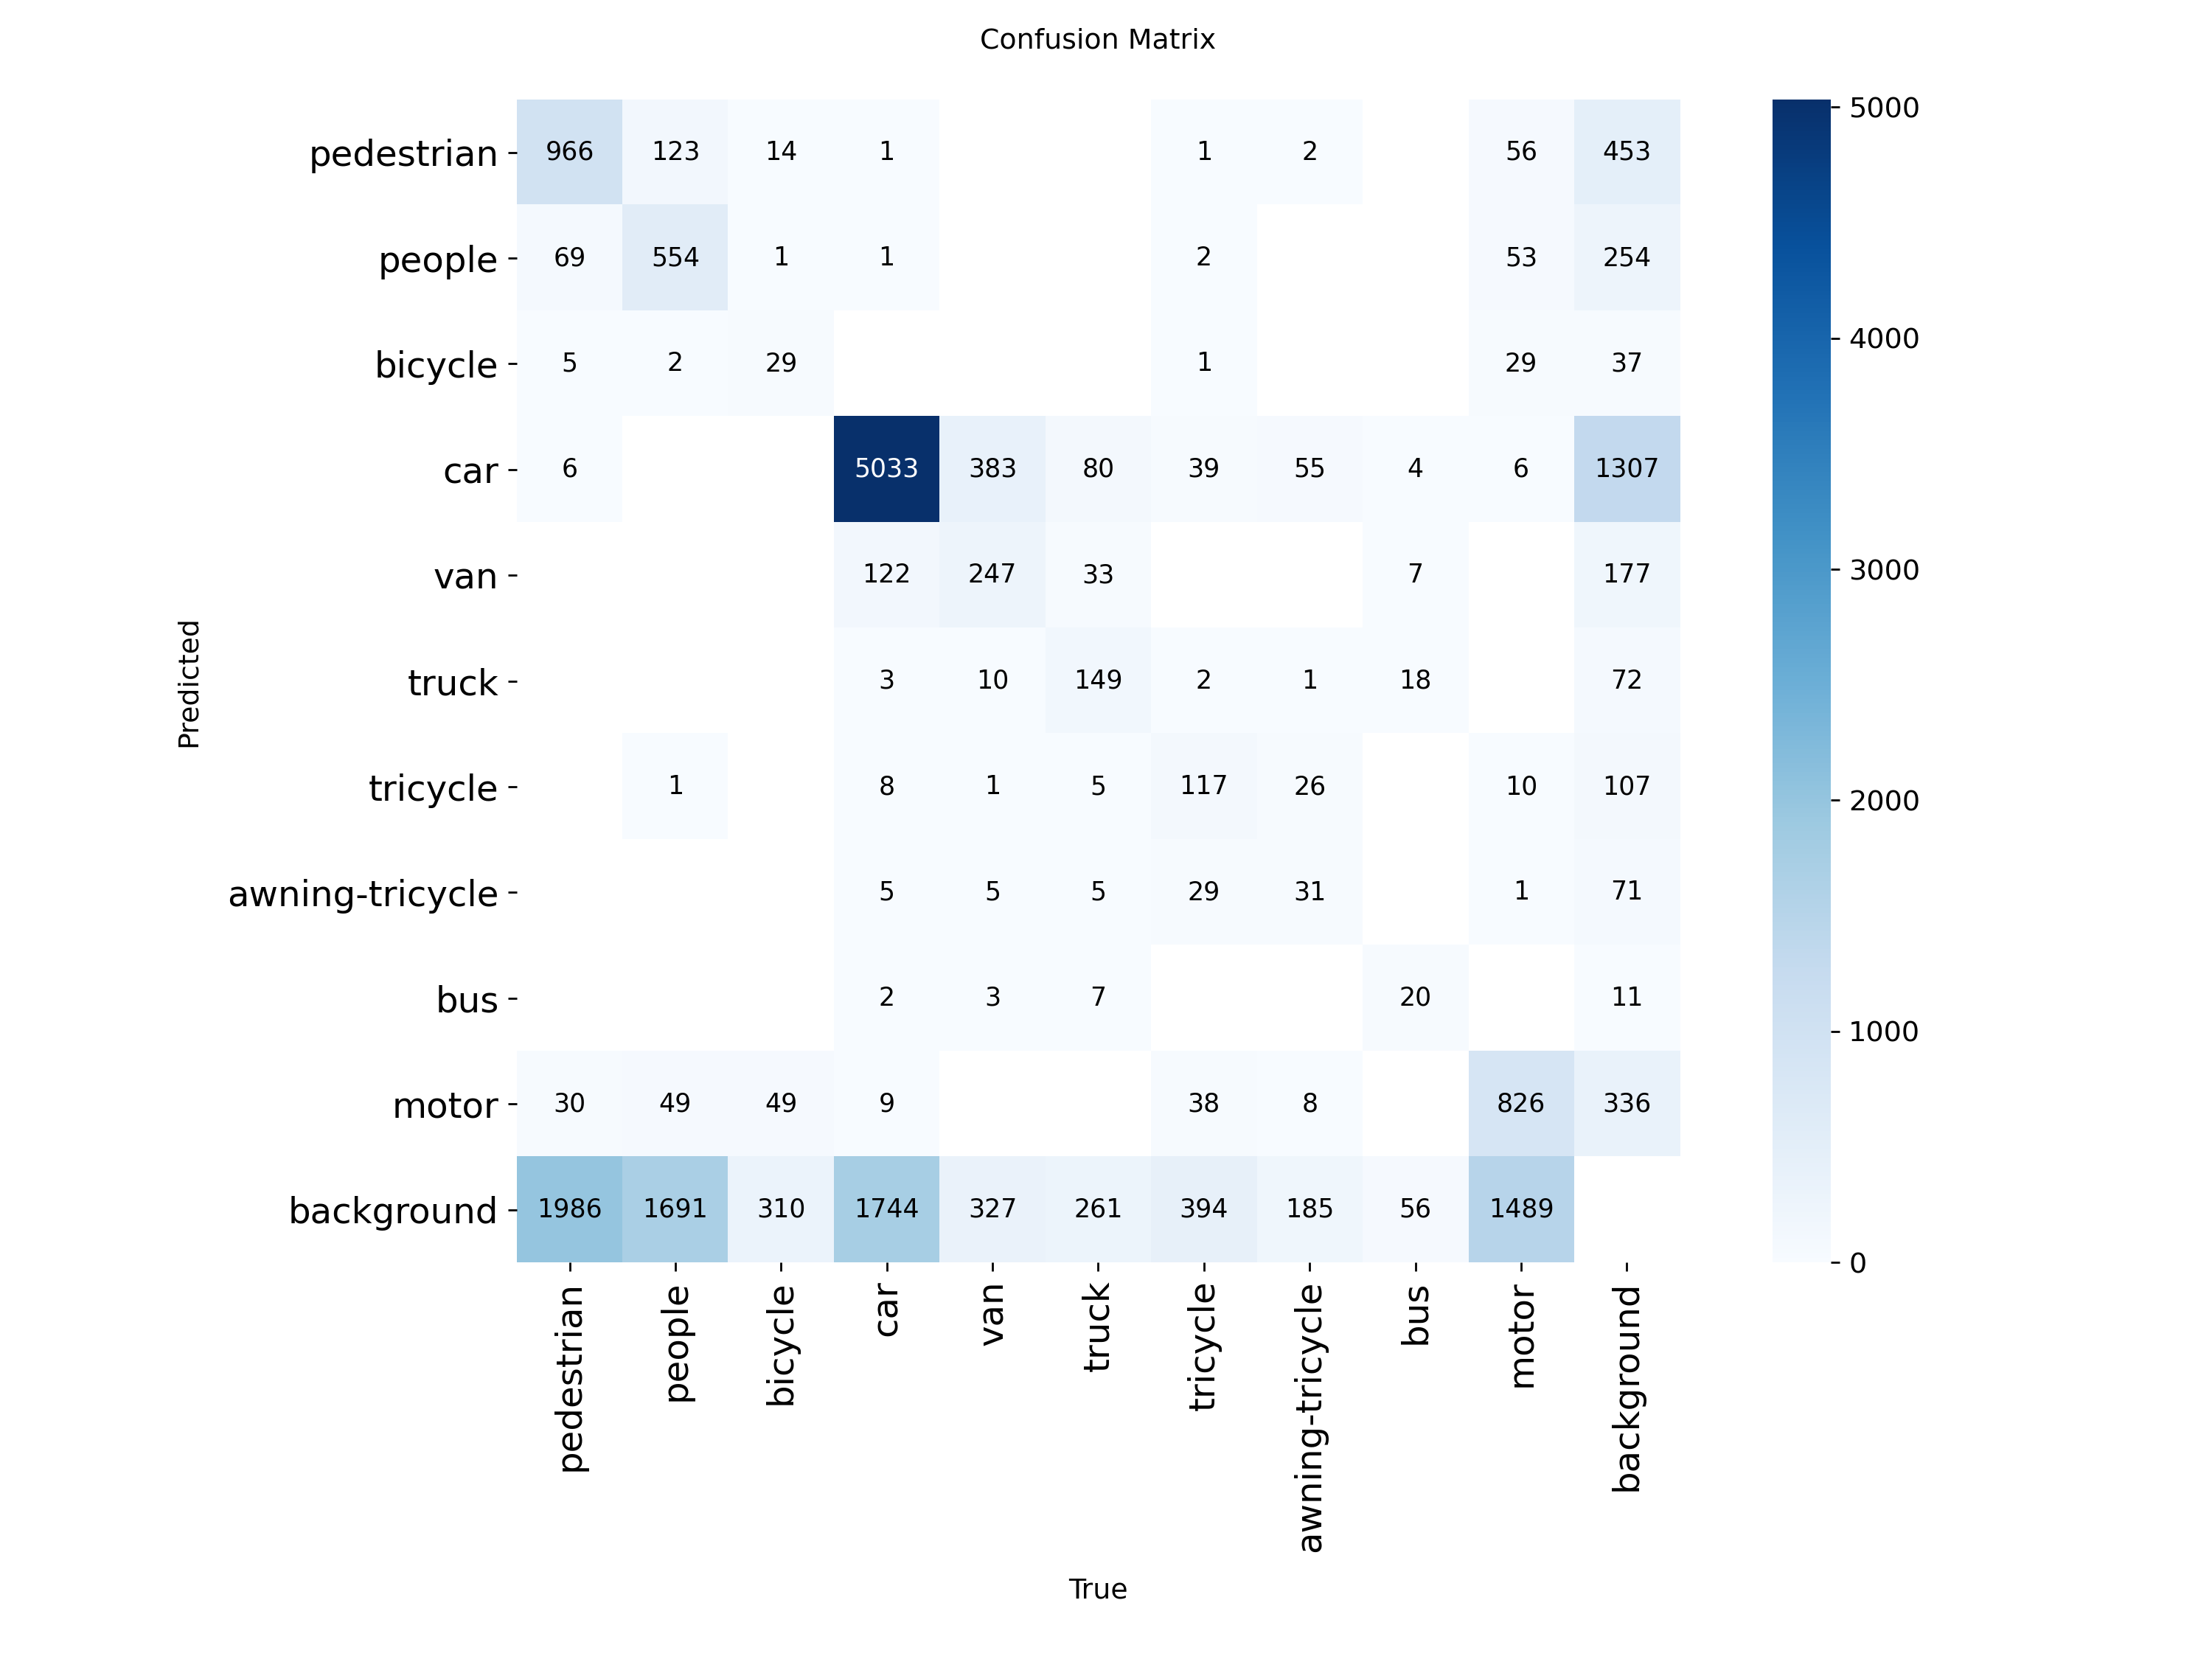

In [6]:
display(Image(f"{BASE}/confusion_matrix.png"))

### **Discussion**

### 4. Confusion Matrix

The confusion matrix shows detections across **all 10 classes**, consistent with previous runs on the same dataset.
The qualitative pattern matches the baseline: **car** is strongest, and small or rare classes remain the hardest.

**Car:**
Cars stay the easiest class, with strong diagonal mass and fewer errors than smaller categories.

**Pedestrian and People:**
Pedestrian and people still trade errors with each other at drone scale, which matches every other VisDrone run in this project.

**Bicycle, Tricycle, and Awning-Tricycle:**
These classes remain weak; size, occlusion, and rarity still limit recall.

**Bus and Van:**
Bus and van look similar to prior runs, with occasional van versus car or truck confusion.

**Overall:**
Despite better mAP and precision, **recall is not dramatically higher**, so many misses still map to background. The improvement is more about **better scoring of detections the model does make** than about discovering every small instance.



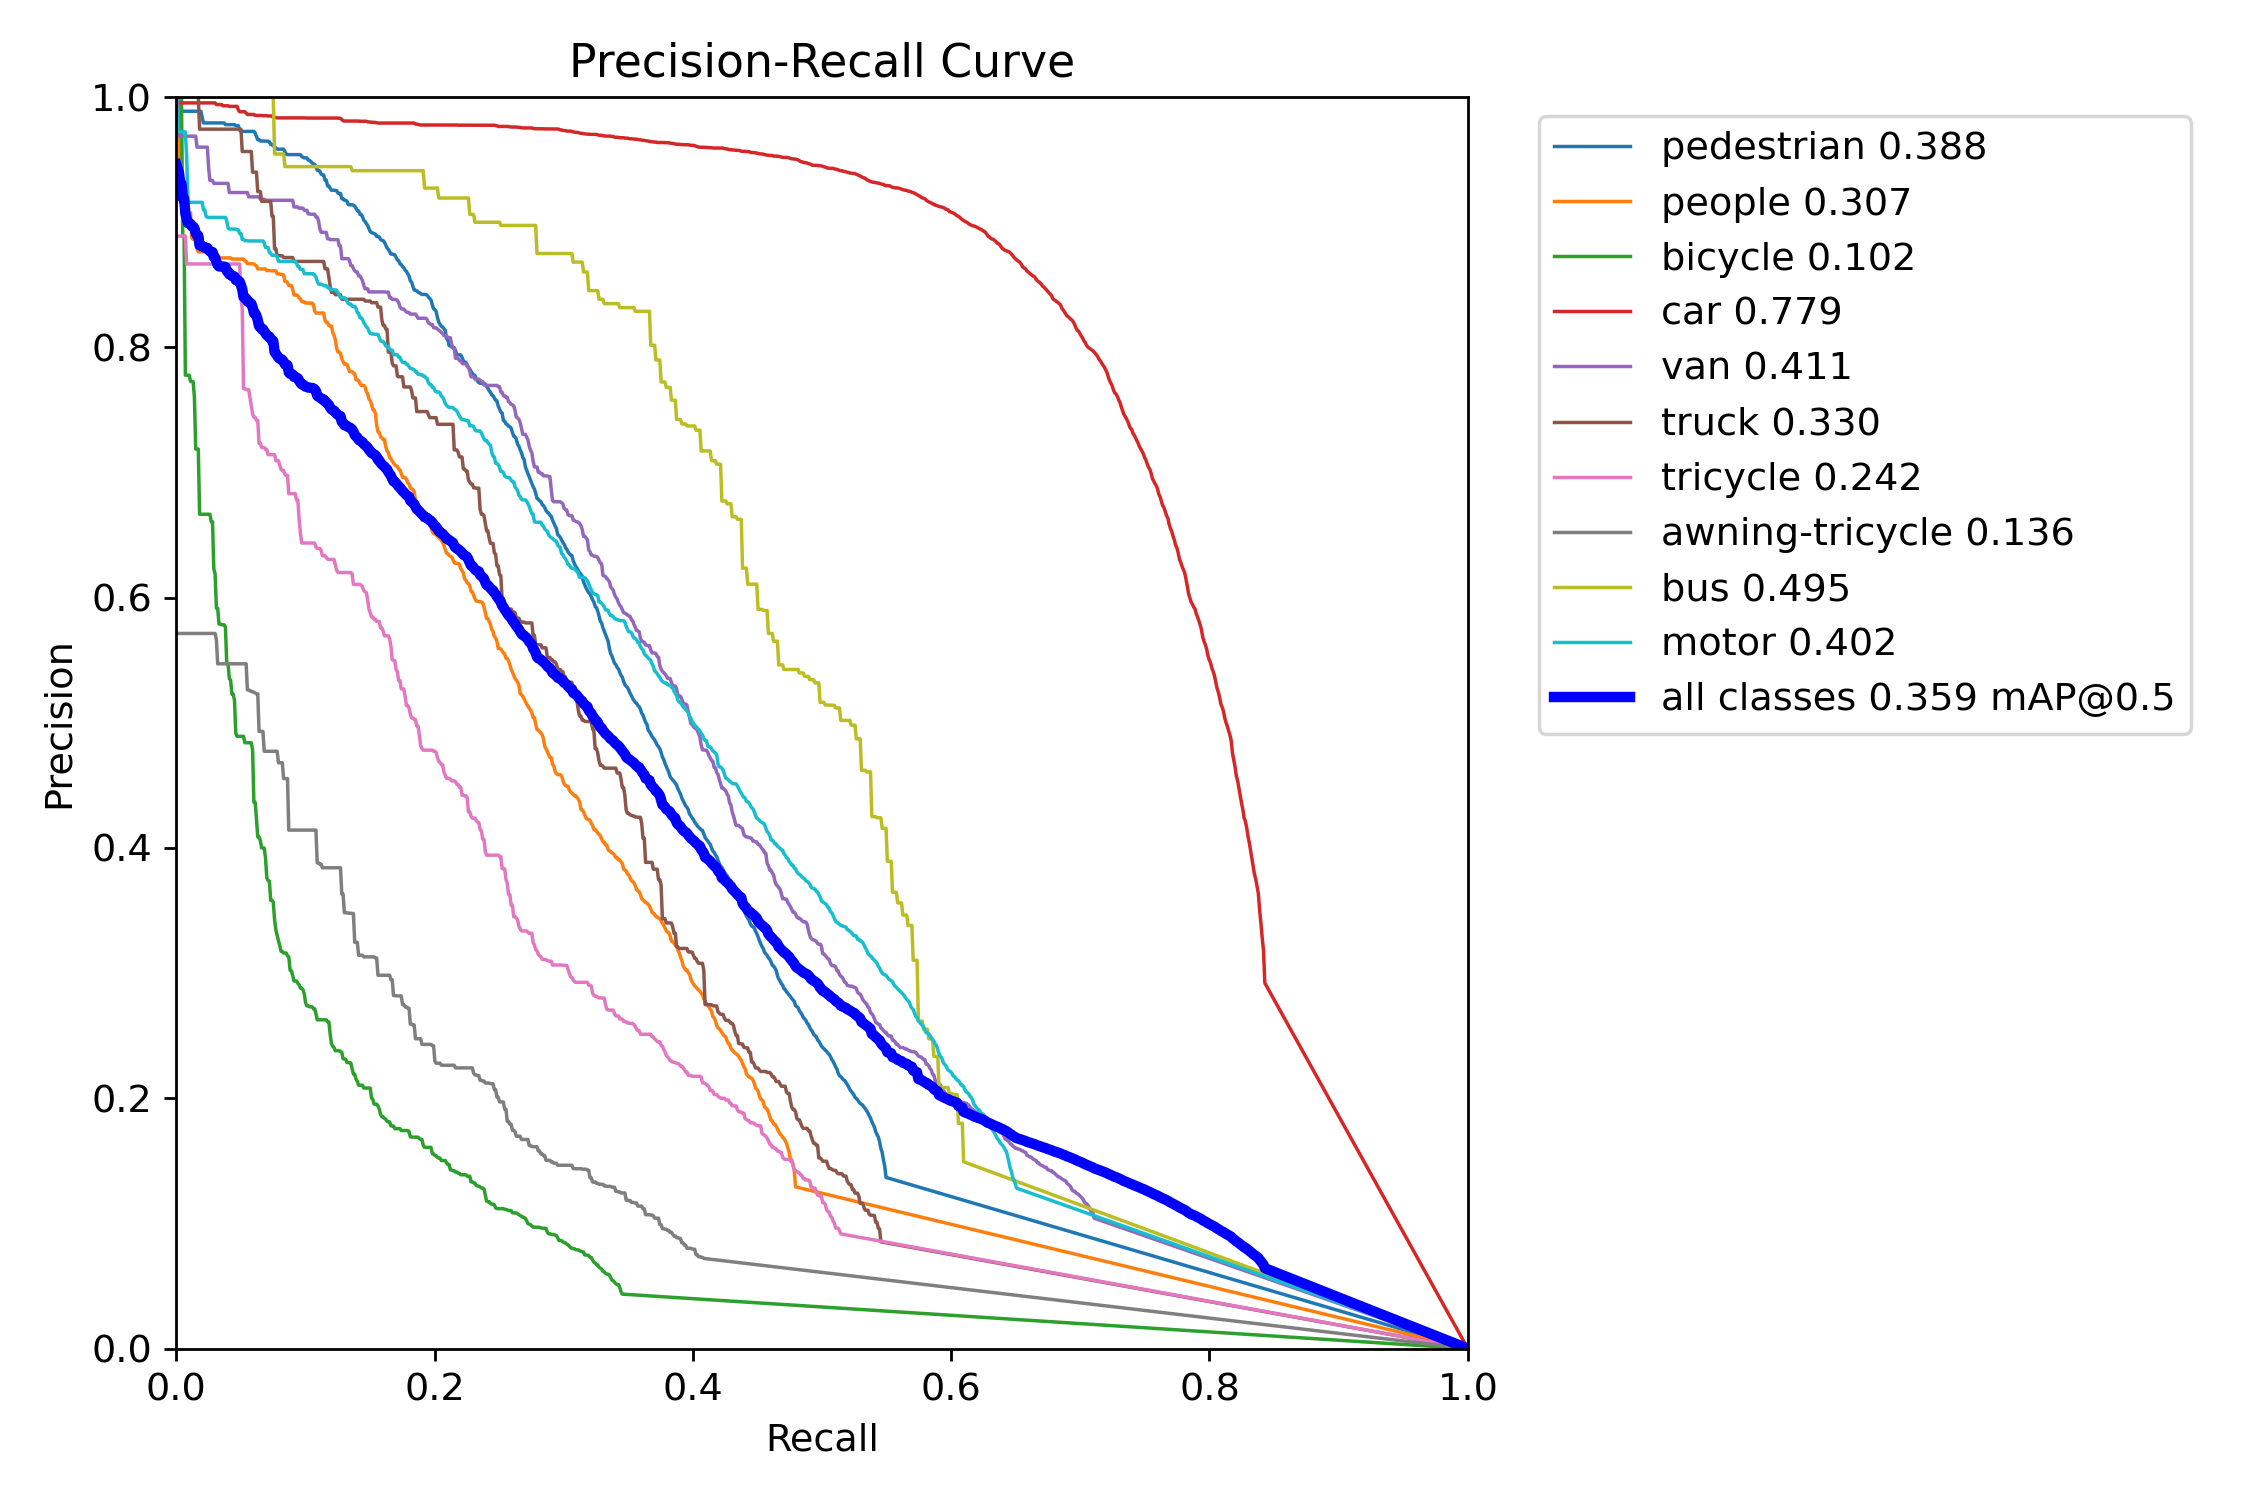

In [7]:
display(Image(f"{BASE}/BoxPR_curve.png"))

### 5. PR Curve (Precision Recall Curve)

The PR curve plots precision against recall at varying confidence thresholds for each class, with the area under each curve representing the per-class average precision.

**Car** leads the pack, as in all previous notebooks.

**Motor** and **bus** sit in the middle, with healthier curves than the tiny vehicle classes.

**Pedestrian** and **people** show earlier precision drops when recall is pushed, consistent with confusion between those classes.

**Bicycle, tricycle, and awning-tricycle** still show the weakest trade-offs.

The overall **mAP@50 of ~0.359** is **higher** than the YOLOv11n baseline (**~0.349**), which aligns with the higher precision and the small, well-controlled train/val loss gap.



### **Discussion Summary**

### 6. Overfitting Analysis

**Mild overfitting** is present but **well controlled**. Evidence:

- Validation box loss (**~1.365**) is slightly above training (**~1.344**), gap **~0.021**.
- The curves track together; there is no extreme late divergence.
- The gap is **not larger** than the baseline’s (**~0.025**); if anything, box-loss generalization is **marginally better** here.

### 7. Underfitting Analysis

There is **no sign of serious underfitting**. Losses decrease across 200 epochs and mAP@50 **exceeds** the baseline. The model clearly learns the task; the remaining errors are mostly the usual VisDrone difficulties (small objects, class confusion, background misses).

### 8. Causes: Architecture and Metric Profile

**Architecture:**

YOLOv8n uses a different backbone and head design than YOLOv11n. Under identical image size, batch, epochs, and patience in this project, that difference shows up as **higher precision and mAP@50** with **similar recall**, which is a favorable trade-off for many deployment settings.

**Metric profile:**

Higher precision with flat recall usually means **fewer false positives at workable thresholds** rather than a big jump in how many ground-truth objects are found. That matches the confusion matrix story: hard classes stay hard, but overall ranking quality improves.



In [8]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,200,0.3595,0.208,0.4751,0.3487


**Summary Table:**

| Observation | What Was Seen | Possible Reason |
|---|---|---|
| Mild, small train/val gap | Box-loss gap ~0.021 | Good alignment of train and val; no strong memorization |
| Full 200 epochs | Patience did not stop early | Late-epoch updates still small but non-trivial |
| Higher mAP@50 than baseline | ~0.359 vs ~0.349 | YOLOv8n fits this VisDrone recipe better for AP@50 |
| Higher precision, similar recall | ~0.475 vs ~0.447 prec.; ~0.349 vs ~0.347 rec. | Model is more confident/calibrated on positives it emits |



### **Part V Note**

This is the **third** of three comparison models in Part V.
YOLOv8n is the strongest of the three on this dataset under your fixed settings: it **beats the baseline on mAP@50 and precision** while keeping recall in line with YOLOv11n, with only mild overfitting and a train/val gap similar to or slightly better than the baseline on box loss.
Together with the YOLOv26n and YOLOv5n runs, these exports support a structured multi-version comparison table in your Part V summary.

